**Question a)**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
k = 3.2e-13
N = 30000.0
G = 30.0
CL_star = 6.0
Vm = 16.0
Ks = 7.0
KCL = 0.3
YOS = 5.0
YPS = 1.5

S0 = 100.0
CL0 = 6.0
P0 = 0.0

y0 = [S0, CL0, P0]

CL_lim = 3 * KCL

kLa = k * N**3 * np.sqrt(G)

print(f"kLa = {kLa:.3f} h^-1")
print(f"Oxygen limitation threshold = {CL_lim:.3f} mg/L")

kLa = 47.323 h^-1
Oxygen limitation threshold = 0.900 mg/L


In [4]:
def reactor_odes(t, y):
    S, CL, P = y
    
    S = max(S, 0)
    CL = max(CL, 0)
    
    rs = Vm * (S / (Ks + S)) * (CL / (KCL + CL))

    dSdt = -rs
    dCLdt = kLa * (CL_star - CL) - YOS * rs
    dPdt = YPS * rs
    
    return [dSdt, dCLdt, dPdt]

In [5]:
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    reactor_odes,
    t_span,
    y0,
    t_eval=t_eval,
    method="BDF",
    rtol=1e-8,
    atol=1e-10
)

t = sol.t
S = sol.y[0]
CL = sol.y[1]
P = sol.y[2]

CL_min = np.min(CL)

print(f"Minimum CL = {CL_min:.3f} mg/L")

if CL_min > CL_lim:
    print("The system is NOT oxygen limited.")
else:
    print("The system is oxygen limited.")

Minimum CL = 4.521 mg/L
The system is NOT oxygen limited.


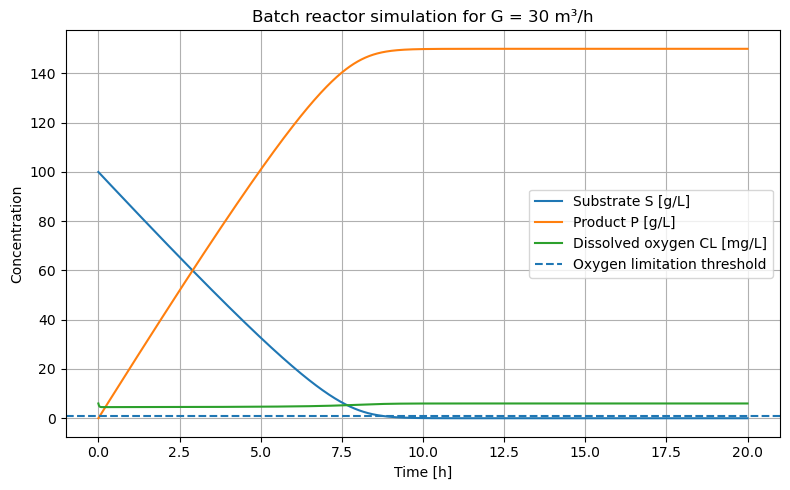

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(t, S, label="Substrate S [g/L]")
plt.plot(t, P, label="Product P [g/L]")
plt.plot(t, CL, label="Dissolved oxygen CL [mg/L]")

plt.axhline(CL_lim, linestyle="--", label="Oxygen limitation threshold")

plt.xlabel("Time [h]")
plt.ylabel("Concentration")
plt.title("Batch reactor simulation for G = 30 m³/h")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Question b)**

In [7]:
from scipy.optimize import brentq

In [8]:
def simulate_for_G(G_value, t_end=60):
    """
    Simulates the batch reactor for a given aeration rate G.
    Returns time, S, CL, P, minimum CL, and kLa.
    """
    
    kLa_value = k * N**3 * np.sqrt(G_value)
    
    def reactor_odes_G(t, y):
        S, CL, P = y
        
        S = max(S, 0)
        CL = max(CL, 0)
        
        rs = Vm * (S / (Ks + S)) * (CL / (KCL + CL))
        
        dSdt = -rs
        dCLdt = kLa_value * (CL_star - CL) - YOS * rs
        dPdt = YPS * rs
        
        return [dSdt, dCLdt, dPdt]
    
    t_eval = np.linspace(0, t_end, 1000)
    
    sol = solve_ivp(
        reactor_odes_G,
        (0, t_end),
        y0,
        t_eval=t_eval,
        method="BDF",
        rtol=1e-8,
        atol=1e-10
    )
    
    t = sol.t
    S = sol.y[0]
    CL = sol.y[1]
    P = sol.y[2]
    
    CL_min = np.min(CL)
    
    return t, S, CL, P, CL_min, kLa_value

In [12]:
G_values = np.linspace(0.1, 30, 300)

CL_min_values = []

for G_value in G_values:
    t, S, CL, P, CL_min, kLa_value = simulate_for_G(G_value)
    CL_min_values.append(CL_min)

CL_min_values = np.array(CL_min_values)

In [13]:
def oxygen_limitation_function(G_value):
    _, _, _, _, CL_min, _ = simulate_for_G(G_value)
    return CL_min - CL_lim

G_critical = brentq(oxygen_limitation_function, 0.1, 30)

_, _, _, _, CL_min_critical, kLa_critical = simulate_for_G(G_critical)

print(f"Critical aeration rate G = {G_critical:.3f} m^3/h")
print(f"Minimum CL at this G = {CL_min_critical:.3f} mg/L")
print(f"kLa at this G = {kLa_critical:.3f} h^-1")

Critical aeration rate G = 1.609 m^3/h
Minimum CL at this G = 0.900 mg/L
kLa at this G = 10.959 h^-1


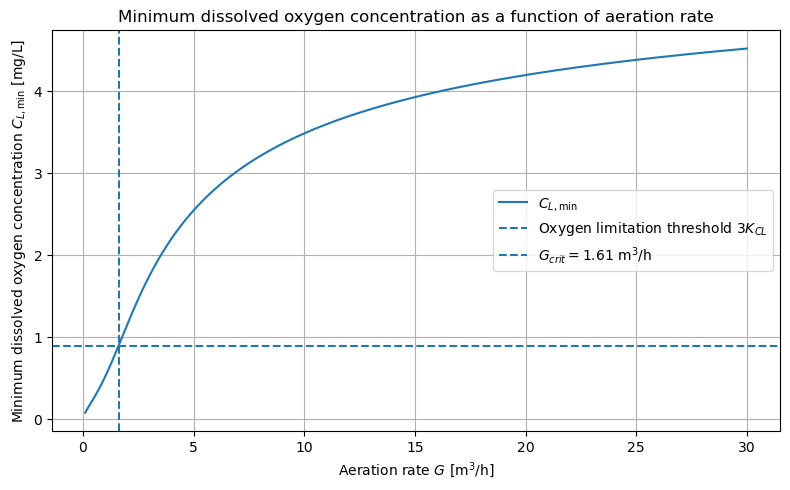

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(G_values, CL_min_values, label=r"$C_{L,\min}$")
plt.axhline(CL_lim, linestyle="--", label=r"Oxygen limitation threshold $3K_{CL}$")
plt.axvline(G_critical, linestyle="--", label=fr"$G_{{crit}} = {G_critical:.2f}$ m$^3$/h")

plt.xlabel(r"Aeration rate $G$ [m$^3$/h]")
plt.ylabel(r"Minimum dissolved oxygen concentration $C_{L,\min}$ [mg/L]")
plt.title(r"Minimum dissolved oxygen concentration as a function of aeration rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("ex1b_CLmin_vs_G.png", dpi=300, bbox_inches="tight")

plt.show()